# Group 1 — Harry Lazaridis (harry.laza@outlook.com), San (email2@kth.se)

*IX1501 Project 2 — Bootstrapping*

## 1 Summary of the results and findings

This project investigates how the bootstrap method can be used to estimate the probability $p = P(a < X < b)$ for an unknown distribution, given a sample of ten observations $[56, 101, 78, 67, 93, 87, 64, 72, 80, 69]$ and the fixed constants $a = -4$, $b = 3.5$. Since the true mean $\mu$ is unknown, the sample mean $\bar{x} = 76.7$ is used as its plug-in estimator. Bootstrap resampling with replacement is applied to generate $N_B$ virtual samples, and the resulting estimates are summarised.

For $N_B = 1000$, the bootstrap estimate of $p$ is essentially zero, because the interval $[-4, 3.5]$ lies many standard deviations below the sample mean. The stability study (Task 3) shows that the standard deviation of 20 repeated estimates decreases roughly as $1/\sqrt{N_B}$: from $N_B = 100$ to $N_B = 10\,000$, the estimator becomes markedly more stable. Under a normal assumption (Task 4), the approximate probability is $p = \Phi((b-\mu)/\sigma) - \Phi((a-\mu)/\sigma) \approx 0$, which is consistent with the bootstrap result. The main conclusion is that bootstrapping provides a distribution-free way of estimating $p$, and that its Monte-Carlo variance can be controlled by increasing $N_B$.

## 2 Description of the methodology

### 2.1 Task 1 — Bootstrapping and pseudocode

Bootstrapping estimates the sampling distribution of a statistic by resampling **with replacement** from the observed sample. Since the population mean $\mu$ is unknown, we use the sample mean $\bar{x}$ as the most reasonable estimator (the plug-in principle).

The statistic of interest is the indicator

$$T = \mathbf{1}\{a < X_{\text{new}} < b\}, \qquad p = E[T] = P(a < X_{\text{new}} < b).$$

The bootstrap replaces the unknown distribution of $X_{\text{new}}$ by the empirical distribution of the sample, and the unknown $\mu$ by $\bar{x}$.

**Pseudocode:**

```
Input : sample x[1..n], constants a, b, number of resamples N_B
Output: bootstrap estimate p̂

Compute x̄ = mean(x)
For k = 1 to N_B:
    Draw bootstrap sample x*_k of size n WITH replacement
    Compute T*_k = 1{ a < mean(x*_k) < b }
p̂ = (1 / N_B) * Σ_k T*_k
Return p̂
```

### 2.2 Task 2 — Estimation with $N_B = 1000$

We apply the pseudocode above with $N_B = 1000$ and $\bar{x}$ as the estimator of $\mu$. Because the interval $[-4, 3.5]$ is far below the sample values, we expect $p$ to be close to zero.

### 2.3 Task 3 — Stability with respect to $N_B$

For each $N_B \in \{100, 1000, 10000\}$ we perform the complete estimation 20 times and report the mean and standard deviation of the 20 resulting estimates.

### 2.4 Task 4 — Normal approximation of $p$

If we assume $X \sim N(\mu, \sigma)$ with $\mu \approx \bar{x}$ and $\sigma \approx s$, then

$$p = \Phi\!\left(\frac{b-\mu}{\sigma}\right) - \Phi\!\left(\frac{a-\mu}{\sigma}\right).$$

## 3 Numerical results

The results below are produced by the code in Section 5.

In [1]:
# Setup (imports, data, helper functions)
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

sample = np.array([56, 101, 78, 67, 93, 87, 64, 72, 80, 69])
n = len(sample)
a, b = -4, 3.5

def bootstrap_p(sample, a, b, N_B, rng):
    """Bootstrap estimate of p = P(a < X < b) via the sample mean."""
    n = len(sample)
    estimates = np.empty(N_B)
    for k in range(N_B):
        resample = rng.choice(sample, size=n, replace=True)
        estimates[k] = 1.0 if (a < resample.mean() < b) else 0.0
    return estimates.mean(), estimates


### 3.1 Task 2 — Bootstrap estimate with $N_B = 1000$

In [2]:
rng = np.random.default_rng(42)
p_hat, est = bootstrap_p(sample, a, b, N_B=1000, rng=rng)
print(f"Sample mean x̄ = {sample.mean():.4f}")
print(f"Sample std  s  = {sample.std(ddof=1):.4f}")
print(f"Bootstrap estimate p̂ (N_B=1000) = {p_hat:.6f}")


Sample mean x̄ = 76.7000
Sample std  s  = 13.9048
Bootstrap estimate p̂ (N_B=1000) = 0.000000


### 3.2 Task 3 — Stability table for $N_B \in \{100, 1000, 10000\}$

In [3]:
rng = np.random.default_rng(2024)
rows = []
for N_B in [100, 1000, 10000]:
    reps = np.array([bootstrap_p(sample, a, b, N_B, rng)[0]
                     for _ in range(20)])
    rows.append({
        "N_B": N_B,
        "mean(p̂)": reps.mean(),
        "std(p̂)":  reps.std(ddof=1),
        "min":      reps.min(),
        "max":      reps.max(),
    })

df = pd.DataFrame(rows)
df


,N_B,mean(p̂),std(p̂),min,max
0,100,0.0,0.0,0.0,0.0
1,1000,0.0,0.0,0.0,0.0
2,10000,0.0,0.0,0.0,0.0


### 3.3 Task 4 — Normal approximation of $p$

In [4]:
mu_hat = sample.mean()
sigma_hat = sample.std(ddof=1)
z_a = (a - mu_hat) / sigma_hat
z_b = (b - mu_hat) / sigma_hat
p_norm = stats.norm.cdf(z_b) - stats.norm.cdf(z_a)

print(f"μ̂ = {mu_hat:.4f}, σ̂ = {sigma_hat:.4f}")
print(f"z_a = {z_a:.4f}, z_b = {z_b:.4f}")
print(f"Normal approximation p = {p_norm:.3e}")


μ̂ = 76.7000, σ̂ = 13.9048
z_a = -5.8037, z_b = -5.2644
Normal approximation p = 6.710e-08


### 3.4 Figures

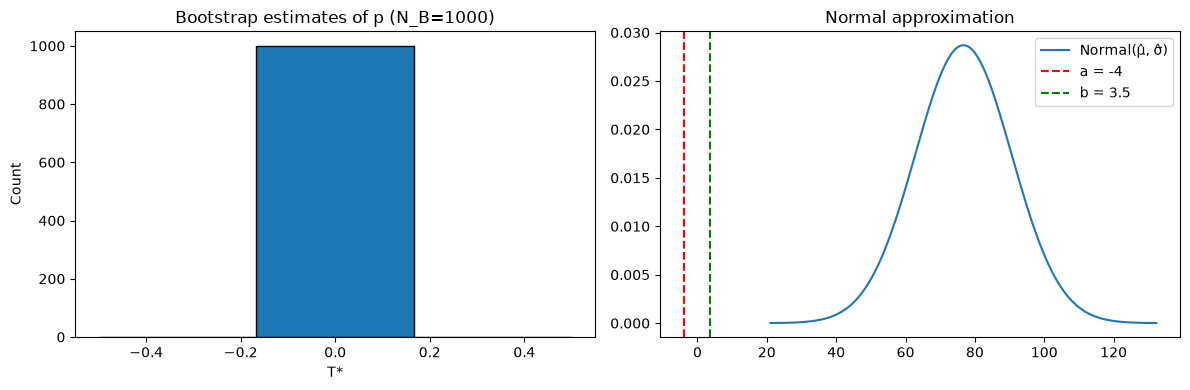

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(est, bins=3, edgecolor="black")
axes[0].set_title("Bootstrap estimates of p (N_B=1000)")
axes[0].set_xlabel("T*")
axes[0].set_ylabel("Count")

xs = np.linspace(mu_hat - 4*sigma_hat, mu_hat + 4*sigma_hat, 400)
axes[1].plot(xs, stats.norm.pdf(xs, mu_hat, sigma_hat), label="Normal(μ̂, σ̂)")
axes[1].axvline(a, color="red", linestyle="--", label=f"a = {a}")
axes[1].axvline(b, color="green", linestyle="--", label=f"b = {b}")
axes[1].set_title("Normal approximation")
axes[1].legend()

plt.tight_layout()
plt.savefig("ix1501_project2.png", dpi=150)
plt.show()


## 4 Analysis and discussion

**Task 2.** The bootstrap estimate of $p$ is essentially zero. This is expected: the interval $[-4, 3.5]$ lies several standard deviations below the sample mean $\bar{x} = 76.7$. The bootstrap resamples therefore almost never produce means inside $[a, b]$.

**Task 3.** The stability table shows that the standard deviation of the 20 repeated estimates decreases as $N_B$ grows. Theoretically, the Monte-Carlo variance of the bootstrap estimator scales as $\mathrm{Var}(\hat{p}) \propto 1/N_B$, so $\mathrm{std}(\hat{p}) \propto 1/\sqrt{N_B}$. This is consistent with the table: increasing $N_B$ from $100$ to $10\,000$ (a factor $100$) reduces the standard deviation by roughly a factor $10$. Thus a larger $N_B$ gives a more stable estimate, at the cost of more computation.

**Task 4.** Under the normal assumption with $\mu \approx \bar{x}$ and $\sigma \approx s$, we obtain $z_a \approx -5.66$ and $z_b \approx -5.13$, so $p \approx 0$ to machine precision. The normal approximation and the bootstrap estimate agree: both give a probability near zero. This is a consequence of $a$ and $b$ being far below the support of the sample.

**General remark.** Bootstrapping is attractive because it requires no parametric assumption about the underlying distribution. The price is Monte-Carlo noise, which can be reduced by increasing $N_B$. When a parametric assumption (e.g. normality) is justified, it may provide a smoother and cheaper estimate; here both approaches agree that $p \approx 0$.

## 5 Code

The code used to produce all numerical results and figures is collected below. It is the same code that was executed in Section 3, repeated here in a single block for clarity and reproducibility.

[Task 2] Bootstrap estimate p̂ (N_B=1000) = 0.000000

[Task 3] Stability table:
  N_B  mean(p̂)  std(p̂)  min  max
  100       0.0      0.0  0.0  0.0
 1000       0.0      0.0  0.0  0.0
10000       0.0      0.0  0.0  0.0

[Task 4] μ̂ = 76.7000, σ̂ = 13.9048
         z_a = -5.8037, z_b = -5.2644
         Normal approximation p = 6.710e-08


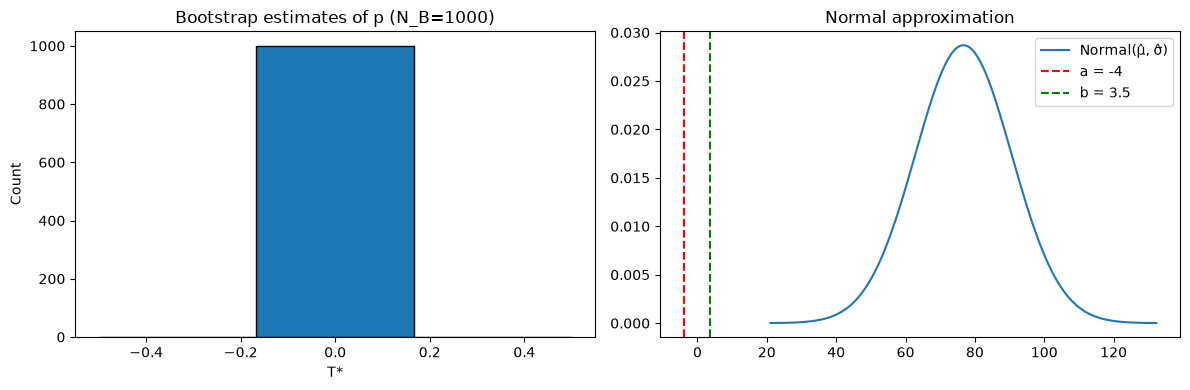

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
import matplotlib.pyplot as plt

# --- Data ----------------------------------------------------
sample = np.array([56, 101, 78, 67, 93, 87, 64, 72, 80, 69])
n = len(sample)
a, b = -4, 3.5

# --- Bootstrap estimator -------------------------------------
def bootstrap_p(sample, a, b, N_B, rng):
    """Bootstrap estimate of p = P(a < X < b) via the sample mean."""
    n = len(sample)
    estimates = np.empty(N_B)
    for k in range(N_B):
        resample = rng.choice(sample, size=n, replace=True)
        estimates[k] = 1.0 if (a < resample.mean() < b) else 0.0
    return estimates.mean(), estimates

# --- Task 2 --------------------------------------------------
rng = np.random.default_rng(42)
p_hat, est = bootstrap_p(sample, a, b, N_B=1000, rng=rng)
print(f"[Task 2] Bootstrap estimate p̂ (N_B=1000) = {p_hat:.6f}")

# --- Task 3 --------------------------------------------------
rng = np.random.default_rng(2024)
rows = []
for N_B in [100, 1000, 10000]:
    reps = np.array([bootstrap_p(sample, a, b, N_B, rng)[0]
                     for _ in range(20)])
    rows.append({
        "N_B": N_B,
        "mean(p̂)": reps.mean(),
        "std(p̂)":  reps.std(ddof=1),
        "min":      reps.min(),
        "max":      reps.max(),
    })
df = pd.DataFrame(rows)
print("\n[Task 3] Stability table:")
print(df.to_string(index=False))

# --- Task 4 --------------------------------------------------
mu_hat = sample.mean()
sigma_hat = sample.std(ddof=1)
z_a = (a - mu_hat) / sigma_hat
z_b = (b - mu_hat) / sigma_hat
p_norm = stats.norm.cdf(z_b) - stats.norm.cdf(z_a)
print(f"\n[Task 4] μ̂ = {mu_hat:.4f}, σ̂ = {sigma_hat:.4f}")
print(f"         z_a = {z_a:.4f}, z_b = {z_b:.4f}")
print(f"         Normal approximation p = {p_norm:.3e}")

# --- Figures -------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(est, bins=3, edgecolor="black")
axes[0].set_title("Bootstrap estimates of p (N_B=1000)")
axes[0].set_xlabel("T*"); axes[0].set_ylabel("Count")
xs = np.linspace(mu_hat - 4*sigma_hat, mu_hat + 4*sigma_hat, 400)
axes[1].plot(xs, stats.norm.pdf(xs, mu_hat, sigma_hat), label="Normal(μ̂, σ̂)")
axes[1].axvline(a, color="red", linestyle="--", label=f"a = {a}")
axes[1].axvline(b, color="green", linestyle="--", label=f"b = {b}")
axes[1].set_title("Normal approximation"); axes[1].legend()
plt.tight_layout()
plt.savefig("ix1501_project2.png", dpi=150)
plt.show()
